In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
ENV_NAME = 'cheetah' # cheetah | walker

In [3]:
BENCHMARK_SET = [0, 1, 2, 3]

NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

KEEP_ONLY_COORDS = False

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
from dm_control import suite

if ENV_NAME == 'cheetah':
    STATE_DIM = 18
    ACTION_DIM = 6
    AUX_DIM = 1
    env = suite.load(
        domain_name='cheetah',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/cheetah_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_cheetah.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 1)), axis=-1)
    
else:
    STATE_DIM = 27
    ACTION_DIM = 6
    AUX_DIM = 3
    env = suite.load(
        domain_name='walker',
        task_name='run',
        environment_kwargs=dict(flat_observation=True)
    )
    dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
    aux = np.load('datasets/aux_walker.npy')
    dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [5]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_):
    return dataset_

def denormalize_dataset_coords(dataset_):
    return dataset_

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [8]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.action_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# FRE:

In [9]:
class MLPRewards:
    def __init__(self, N, obs_len):

        self.param_w1 = torch.normal(0, 1, size=(N, obs_len, 32)) * np.sqrt(1/32)
        self.param_b1 = torch.normal(0, 1, size=(N, 1, 32)) * np.sqrt(16)
        self.param_w2 = torch.normal(0, 1, size=(N, 32, 1)) * np.sqrt(1/16)
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
            
    
    def __len__(self):
        return self.param_w1.shape[0]
    
    def sample(self, N):
        return torch.randint(0, len(self), (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, len(self), size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded].to(device)
        param1_b = self.param_b1[param_id_expanded].to(device)
        param2_w = self.param_w2[param_id_expanded].to(device)

        # obs[..., 2:] = 0.0

        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        x = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        x = x + param1_b
        x = torch.tanh(x)
        r = torch.matmul(x, param2_w) # [batch, (pairs), 1, 1]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id
    
# mlp_rewards = MLPRewards(N=10000, obs_len=29)

In [10]:
class LinearRewards:
    def __init__(self, N, obs_len):

        
        self.param_w1 = torch.rand(size=(N, obs_len, 1)) * 2 - 1
        self.random_mask = torch.rand(size=(N, obs_len)) < 0.9
        # self.random_mask[..., :2] = True
        
        random_mask_positive = np.random.randint(2, obs_len, size=(N,))
        self.random_mask[np.arange(N), random_mask_positive] = False # Force at least one positive weight.
        
        if obs_len == 18:
            self.param_w1[:, -1:] = 0
        elif obs_len == 27:
            self.param_w1[:, -3:] = 0
            
            
    def __len__(self):
        return self.param_w1.shape[0]
        

    def sample(self, N):
        return torch.randint(0, len(self), (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, len(self), size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded].to(device)
        mask = self.random_mask[param_id_expanded].to(device)
        obs = (~mask) * obs
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        r = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id

In [11]:
class GoalRewards:
    def __init__(self):
        pass
    
    def sample_goals(self, N):
        goals = dataset_trajectories[
            torch.randint(0, num_trajectories, (N,)),
            torch.randint(0, len_trajectory, (N,)),
        ]
        return goals
    
    # def get_states(self, num_states, goals):
    #     cond = (dataset_trajectories[..., :2] - goal[..., :2]).norm(dim=-1) < 0.5
    #     dataset_trajectories_cuda[cond][torch.randint(0, cond.sum(), (1,))]
    
    def __call__(self, obs, goals=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param.shape = (batch_size, obs_dim)
        """
        
        if obs.shape[-1] == 18:
            std = torch.tensor([[0.4407440506721877, 10.070289916801876, 0.5172332956856273, 0.5601041145815341, 0.518947027289748, 0.3204431592542281, 0.5501848643154092, 0.3856393812067661, 1.9882502334402663, 1.6377168569884073, 4.308505013609855, 12.144181770553105, 13.537567521831702, 16.88983033626308, 7.715009572436841, 14.345667964212357, 10.6904255152284, 100]])
        elif obs.shape[-1] == 27:
            std = torch.tensor([[0.7212967364054736, 0.6775020895964047, 0.7638155887842976, 0.6395721376821286, 0.6849394775886244, 0.7078581708129903, 0.7113168519036742, 0.6753408522523937, 0.6818095329625652, 0.7133958718133511, 0.65227578338642, 0.757622576816855, 0.7311826446274479, 0.6745824928740024, 0.36822491550384456, 2.1134839667805805, 1.813353841099317, 10.594648894374815, 17.41041469033713, 17.836743227082106, 22.399097178637533, 16.1492222730888, 15.693574546557201, 18.539929326905067, 100, 100, 100]])

        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, obs_dim_ = goals.shape
        assert (batch_size == batch_size_) and (obs_dim == obs_dim_)
        
        device = obs.device
        
        goals = goals.to(device)

        # r = torch.norm(obs - goals.unsqueeze(-2), dim=-1) < 2
        dists_per_dim = obs - goals.unsqueeze(-2)
        dists_per_dim = dists_per_dim / std.to(device)
        dists = torch.norm(dists_per_dim, dim=-1) / obs.shape[-1]
        r = (dists < 0.2)
        r = r.float() * 2 - 1
        r = torch.clip(r, -1, 1)

        return r, goals


In [12]:
linear_rewards = LinearRewards(N=1000, obs_len=STATE_DIM)
mlp_rewards = MLPRewards(N=1, obs_len=STATE_DIM)
goal_rewards = GoalRewards()

In [13]:
def sample_reward_function_fre(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, STATE_DIM).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))

    for b in range(batch_size):
        # reward_type = torch.randint(0, 3, (1,)) # 0: goal_reaching | 1: linear_reward | 2: mlp_reward
        reward_type = torch.randint(1, 3, (1,))   # 1: linear_reward | 2: mlp_reward
        
        reward_type = 1
        
        reward_params[b, 0] = reward_type
        if reward_type == 0:
            goal = goal_rewards.sample_goals(1)
            goal = goal.repeat(1, 1)
            r, param_id = goal_rewards(random_states[[b]], goals=goal)    
            reward_params[b, 1:1+obs_dim] = param_id
            random_states[b, 0] = goal
            r[0, 0] = 1.
            
        elif reward_type == 1:
            param_id = linear_rewards.sample(1).unsqueeze(0)
            r, param_id = linear_rewards(random_states[[b]], param_id)
            reward_params[b, 1] = param_id
            
        elif reward_type == 2:
            param_id = mlp_rewards.sample(1).unsqueeze(0)
            r, param_id = mlp_rewards(random_states[[b]], param_id) 
            reward_params[b, 1] = param_id
            
        random_states_rewards[b] = r
        
    return reward_params, random_states, random_states_rewards

# FRE:

In [14]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )


    def get_transformer_encoding(self, reward_state_pairs):
        reward_states = reward_state_pairs[:, :, :-1]
        reward_values = reward_state_pairs[:, :, -1]
        reward_values_idx = torch.floor((reward_values / 2.0 + 0.5) * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        reward_state_emb = self.state_embed(reward_states)
        reward_state_val = self.reward_embed(reward_values_idx)
        
        reward_state_pairs = torch.concatenate([reward_state_emb, reward_state_val], axis=-1)

        w_pre = self.encoder_transformer(reward_state_pairs) # [batch, reward_pairs, emb_dim]
        
        w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [15]:
class VelocityRewardFunctionCheetah:
    def __init__(self):
        pass    
    
    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
        else:
            raise NotImplementedError
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='linear', value_at_margin=0):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return value
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        horizontal_velocity = states[..., 17:18]
        sign_of_param = np.sign(params)
        horizontal_velocity = horizontal_velocity * sign_of_param
        rew = self.tolerance(horizontal_velocity,
                             lower=np.abs(params),
                             upper=float('inf'),
                             margin=np.abs(params),
                             value_at_margin=0,
                             sigmoid='linear')
        
        return torch.tensor(rew[..., 0])
    
    
    
class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int) or isinstance(params, float):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        _STAND_HEIGHT = 1.2
        horizontal_velocity = states[..., 24:25]
        torso_upright = states[..., 25:26]
        torso_height = states[..., 26:27]
        standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
        upright = (1 + torso_upright) / 2
        stand_reward = (3*standing + upright) / 4
        move_reward = self.tolerance(horizontal_velocity,
                                        lower=params,
                                        upper=float('inf'),
                                        margin=params/2,
                                        value_at_margin=0.5,
                                        sigmoid='linear')
        # move_reward[params == 0] = stand_reward[params == 0]
        rew = stand_reward * (5*move_reward + 1) / 6
        # rew = (5*move_reward + 1) / 6
        
        return torch.tensor(rew[..., 0])



if ENV_NAME == 'cheetah':
    velocity_reward_function = VelocityRewardFunctionCheetah()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel10Back', -10),
        (velocity_reward_function.compute_reward, 'vel2Back', -2),
        (velocity_reward_function.compute_reward, 'vel2', 2),
        (velocity_reward_function.compute_reward, 'vel10', 10),
    ]
elif ENV_NAME == 'walker':
    velocity_reward_function = VelocityRewardFunctionWalker()
    benchmarks = [
        (velocity_reward_function.compute_reward, 'vel0.1', 0.1),
        (velocity_reward_function.compute_reward, 'vel1', 1),
        (velocity_reward_function.compute_reward, 'vel4', 4),
        (velocity_reward_function.compute_reward, 'vel8', 8),
    ]
    
benchmarks = [benchmarks[i] for i in BENCHMARK_SET]

In [16]:
def get_reward(reward_params, random_states):

    assert len(reward_params.shape) == 2
    assert len(random_states.shape) == 3
    assert reward_params.shape[0] == random_states.shape[0]
    
    all_rewards = torch.zeros((random_states.shape[0], random_states.shape[1]), device=device)

    for b in range(reward_params.shape[0]):
        param = reward_params[b]
        x = random_states[b].unsqueeze(0)
        if (param[0] == 2):
            rewards, _ = mlp_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
        elif (param[0] == 1):
            rewards, _ = linear_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
        elif (param[0] == 0):
            rewards, _ = goal_rewards(obs=x, goals=param[1:obs_dim+1].unsqueeze(0).repeat(x.shape[0], 1))
        elif (param[0] == 5):
            benchmark_id = int(param[1].item())
            benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
            rewards, _ = goal_rewards(obs=x, goals=param[1:obs_dim+1].unsqueeze(0).repeat(x.shape[0], 1))
            rewards = benchmark_reward_function(x.cpu(), benchmark_param)
        else:
            raise NotImplementedError(f'reward function with type {param[0]} is not implemented')
        
        all_rewards[b] = rewards.float()

    return all_rewards


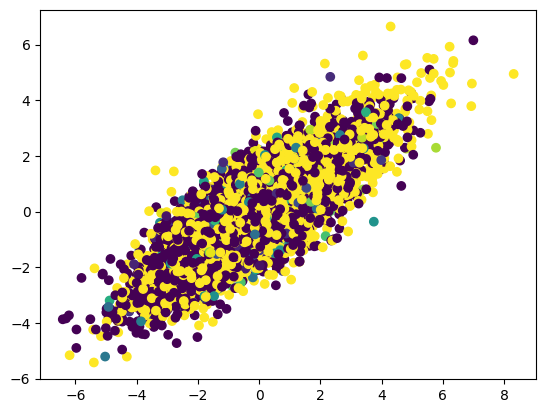

In [17]:
num_eval_states = 10_000

reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=(128+num_eval_states))

decode_obs = random_states[:, 128:, :].to(device)
decode_rewards = random_states_rewards[:, 128:, None].to(device)
    
    
if ENV_NAME == 'walker':
    plt.scatter(decode_obs[..., 16].cpu(), decode_obs[..., 24].cpu(), c=decode_rewards.cpu(), vmin=-1, vmax=1)
    
if ENV_NAME == 'cheetah':
    plt.scatter(decode_obs[..., 8].cpu(), decode_obs[..., 17].cpu(), c=decode_rewards.cpu(), vmin=-1, vmax=1)


0.0777406394481659


(-1.0, 1.0)

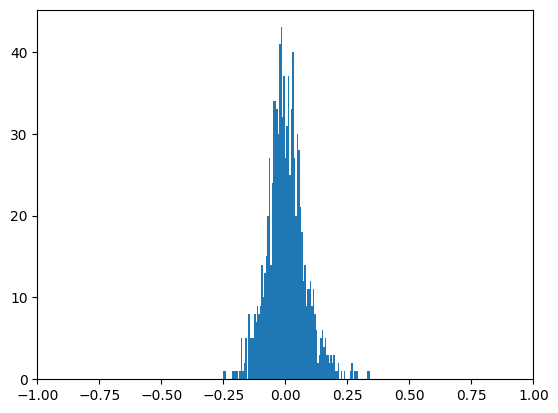

In [18]:
with torch.no_grad():
    if ENV_NAME == 'walker':
        r = get_reward(reward_params, random_states=dataset_trajectories[:1000, ::10].reshape(1, -1, 27))
    elif ENV_NAME == 'cheetah':
        r = get_reward(reward_params, random_states=dataset_trajectories[:1000, ::10].reshape(1, -1, 18))
        
    std = r.reshape(1000, 100).mean(dim=1).std().item()
    
    print(std)
    
    
    
plt.hist(r.reshape(1000, 100).mean(dim=1).cpu(), bins=100)
plt.xlim([-1, 1])

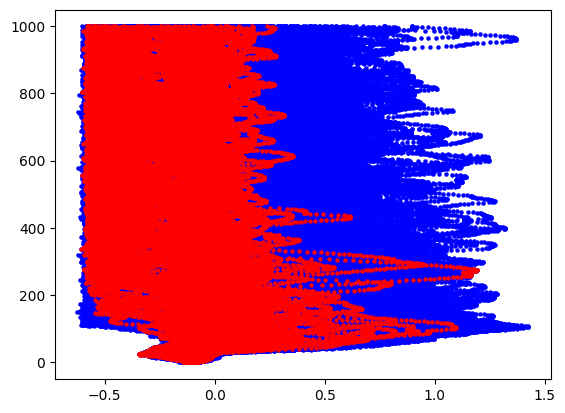

In [19]:
topk = 50
ids = r.reshape(1000, 100).mean(dim=1).cpu().argsort()[-topk:]
# ids = r.reshape(1000, 100).mean(dim=1).cpu().argsort()[:topk]


plt.scatter(
    dataset['physics'][:1000, :, 1],
    torch.arange(1000).reshape(1, -1).repeat(1000, 1),
    c='blue', s=5
)

plt.scatter(
    dataset['physics'][ids, :, 1],
    torch.arange(1000).reshape(1, -1).repeat(topk, 1),
    c='red', s=5
)

100%|██████████| 1/1 [00:00<00:00, 20.87it/s]


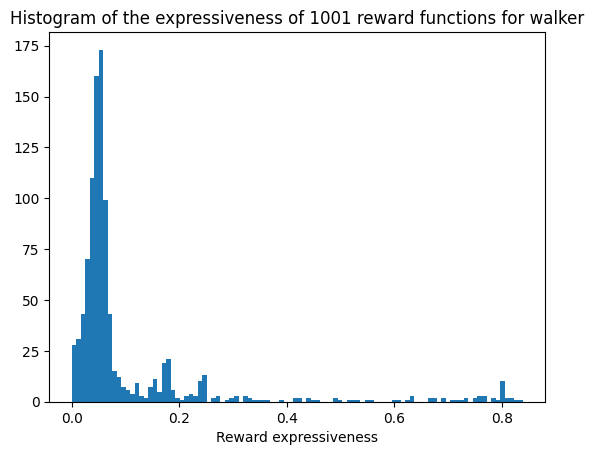

In [21]:
def get_best_reward_function_ids():
    stds = []

    for reward_type in [1, 2]:

        num_functions = len(linear_rewards) if reward_type == 1 else len(mlp_rewards)
        
        for i in tqdm(range(num_functions)):
        
            with torch.no_grad():
                
                reward_params = torch.zeros((1, 128))
                reward_params[0, 0] = reward_type
                reward_params[0, 1] = i
                
                r = get_reward(reward_params, random_states=dataset_trajectories[::10, ::10].reshape(1, -1, 18))
                std = r.reshape(1000, 100).mean(dim=1).std().item()
                stds.append(std)
            
            # print(std)
            
        
    stds = torch.tensor(stds)

    plt.plot()
    _ = plt.hist(stds, bins=100)
    plt.xlabel('Reward expressiveness')
    plt.title(f'Histogram of the expressiveness of {len(linear_rewards)+len(mlp_rewards)} reward functions on {ENV_NAME}')


    sorted_ids = stds.argsort()


    top_rewards_ids = sorted_ids[-500:]
    ids_to_keep_linear = top_rewards_ids[(top_rewards_ids // len(linear_rewards)) == 0] % len(linear_rewards)
    ids_to_keep_mlp = top_rewards_ids[(top_rewards_ids // len(linear_rewards)) == 1] % len(linear_rewards)
    
    return ids_to_keep_linear, ids_to_keep_mlp

In [22]:
# linear_rewards.param_w1 = linear_rewards.param_w1[ids_to_keep_linear]
# linear_rewards.random_mask = linear_rewards.random_mask[ids_to_keep_linear]


# mlp_rewards.param_w1 = mlp_rewards.param_w1[ids_to_keep_mlp]
# mlp_rewards.param_b1 = mlp_rewards.param_b1[ids_to_keep_mlp]
# mlp_rewards.param_w2 = mlp_rewards.param_w2[ids_to_keep_mlp]

1 554


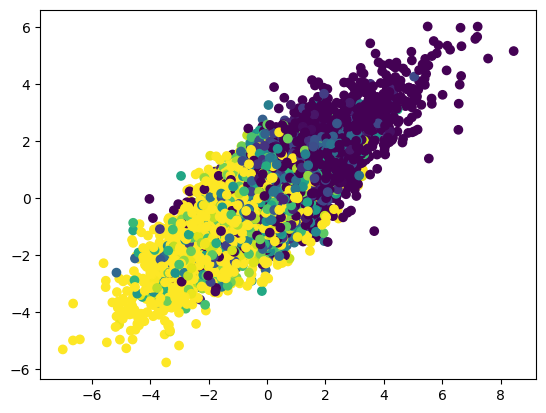

0.24331621825695038


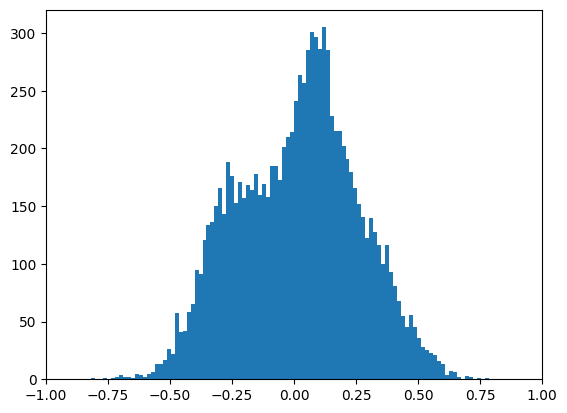

In [34]:
rel_id = stds.argsort()[-100].item()

reward_type, id = rel_id // len(linear_rewards) + 1, rel_id % len(linear_rewards)
print(reward_type, id)

reward_params = torch.zeros((1, 128))
reward_params[0, 0] = reward_type
reward_params[0, 1] = id


trajectories_idx = torch.randint(0, num_trajectories, (10000,))
states_idx = torch.randint(0, len_trajectory, (10000,))
decode_obs = dataset_trajectories[trajectories_idx, states_idx] # get the random states
decode_obs = decode_obs.reshape(1, -1, 18)

decode_rewards = r = get_reward(reward_params, random_states=decode_obs)
    
    
if ENV_NAME == 'walker':
    plt.scatter(decode_obs[..., 16].cpu(), decode_obs[..., 24].cpu(), c=decode_rewards.cpu(), vmin=-1, vmax=1)
    
if ENV_NAME == 'cheetah':
    plt.scatter(decode_obs[..., 8].cpu(), decode_obs[..., 17].cpu(), c=decode_rewards.cpu(), vmin=-1, vmax=1)

plt.show()


with torch.no_grad():
    
    r = get_reward(reward_params, random_states=dataset_trajectories[:10000, ::10].reshape(1, -1, 18))
    
    std = r.reshape(10000, 100).mean(dim=1).std().item()
    
    print(std)
    
    
    
plt.hist(r.reshape(10000, 100).mean(dim=1).cpu(), bins=100)
plt.xlim([-1, 1])
plt.show()

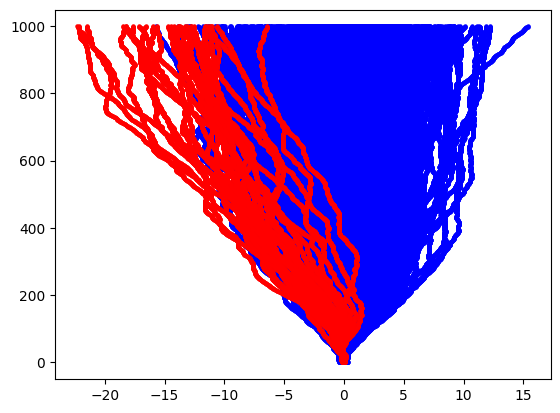

In [35]:
topk = 30
ids = r.reshape(10000, 100).mean(dim=1).cpu().argsort()[-topk:]
# ids = r.reshape(1000, 100).mean(dim=1).cpu().argsort()[:topk]



plt.scatter(
    dataset['physics'][:1000, :, 0],
    torch.arange(1000).reshape(1, -1).repeat(1000, 1),
    c='blue', s=5
)

plt.scatter(
    dataset['physics'][ids, :, 0],
    torch.arange(1000).reshape(1, -1).repeat(topk, 1),
    c='red', s=5
)